In [1]:
import os

os.environ['HTTP_PROXY'] = 'http://127.0.0.1:10808'
os.environ['HTTPS_PROXY'] = 'http://127.0.0.1:10808'
os.environ['NO_PROXY'] = 'localhost,127.0.0.1'

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, PolynomialFeatures
import kagglehub
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
from xgboost import XGBRegressor

/home/miad/.local/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:

# Download latest version
path = kagglehub.dataset_download("austinreese/craigslist-carstrucks-data")

print("Path to dataset files:", path)

Path to dataset files: /home/miad/.cache/kagglehub/datasets/austinreese/craigslist-carstrucks-data/versions/10


In [4]:
for f in os.listdir(path):
    print(f)

vehicles.csv


In [5]:
pd.set_option('display.float_format', '{:.2f}'.format)
csv_path = os.path.join(path, "vehicles.csv")
df = pd.read_csv(csv_path)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

In [7]:
df = df.drop(columns=["id", "url","region_url","VIN", "description", "image_url"])
# dropping county since it is all null
# size and posting_datecause it has a lot of null
# paint does not have corr
df = df.drop(columns=["county", "lat", "long", "region", "paint_color", "size", "posting_date", "title_status"])

# dropping rows with null value in price, year, model, manufacturer
df = df.dropna(subset=['price', 'year', 'model', 'manufacturer'])

In [8]:

# Fill missing categorical features with 'unknown'
for col in ['condition', 'drive', 'type', 'fuel']:
    df[col] = df[col].fillna('unknown')

# Fill missing transmission with most common value
df['transmission'] = df['transmission'].fillna(df['transmission'].mode()[0])

# Clean cylinders (convert text like '6 cylinders' → 6)
df['cylinders'] = df['cylinders'].str.extract(r'(\d+)').astype(float)
df['cylinders'] = df['cylinders'].fillna(df['cylinders'].median())

df = df[df["odometer"].between(0, 350_000)]
df = df[df["price"].between(300, 80_000)]
df = df[df["year"] > 1980]

In [9]:
# convert objects to category
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype('category')

In [10]:
#    keep=False marks ALL rows that are part of any duplicate set as True.
all_duplicates_mask = df.duplicated(keep=False)

all_duplicate_rows_df = df[all_duplicates_mask]

# 3. Sort them to see them grouped together
print("All rows that are part of a duplicate set:")
display(all_duplicate_rows_df.sort_values(by=['manufacturer', 'model', 'year', 'price']))

print(f"Shape before dropping duplicates: {df.shape}")

df = df.drop_duplicates()

print(f"Shape after dropping duplicates: {df.shape}")
print(f"Total duplicates found: {df.duplicated().sum()}")

All rows that are part of a duplicate set:


,price,year,manufacturer,model,condition,cylinders,fuel,odometer,transmission,drive,type,state
332564,9999,2003.00,acura,3.2 cl type s,excellent,6.00,gas,136371.00,manual,unknown,coupe,pa
333080,9999,2003.00,acura,3.2 cl type s,excellent,6.00,gas,136371.00,manual,unknown,coupe,pa
56686,7799,2008.00,acura,3.2 tl,excellent,6.00,gas,117000.00,automatic,unknown,unknown,ca
56687,7799,2008.00,acura,3.2 tl,excellent,6.00,gas,117000.00,automatic,unknown,unknown,ca
108696,3695,2001.00,acura,cl,unknown,6.00,gas,195578.00,automatic,unknown,coupe,fl
...,...,...,...,...,...,...,...,...,...,...,...,...
42957,42998,2018.00,volvo,xc90t6 awd 24733 miles,excellent,6.00,gas,24733.00,automatic,4wd,SUV,ca
57532,42998,2018.00,volvo,xc90t6 awd 24733 miles,excellent,6.00,gas,24733.00,automatic,4wd,SUV,ca
57582,42998,2018.00,volvo,xc90t6 awd 24733 miles,excellent,6.00,gas,24733.00,automatic,4wd,SUV,ca
57869,42998,2018.00,volvo,xc90t6 awd 24733 miles,excellent,6.00,gas,24733.00,automatic,4wd,SUV,ca


Shape before dropping duplicates: (357429, 12)
Shape after dropping duplicates: (250995, 12)
Total duplicates found: 0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 250995 entries, 27 to 426879
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype   
---  ------        --------------   -----   
 0   price         250995 non-null  int64   
 1   year          250995 non-null  float64 
 2   manufacturer  250995 non-null  category
 3   model         250995 non-null  category
 4   condition     250995 non-null  category
 5   cylinders     250995 non-null  float64 
 6   fuel          250995 non-null  category
 7   odometer      250995 non-null  float64 
 8   transmission  250995 non-null  category
 9   drive         250995 non-null  category
 10  type          250995 non-null  category
 11  state         250995 non-null  category
dtypes: category(8), float64(3), int64(1)
memory usage: 12.4 MB


In [12]:
df.describe()

,price,year,cylinders,odometer
count,250995.00,250995.00,250995.00,250995.00
mean,17564.04,2011.56,5.92,97422.85
std,13595.21,6.54,1.25,63431.76
min,300.00,1981.00,3.00,0.00
25%,6980.00,2008.00,6.00,42835.50
50%,13995.00,2013.00,6.00,93424.00
75%,25487.50,2017.00,6.00,140371.50
max,80000.00,2022.00,12.00,350000.00


In [13]:
df.isnull().sum().sort_values(ascending=False)

price           0
year            0
manufacturer    0
model           0
condition       0
cylinders       0
fuel            0
odometer        0
transmission    0
drive           0
type            0
state           0
dtype: int64

In [14]:
df.shape

(250995, 12)

In [15]:
df.tail()

,price,year,manufacturer,model,condition,cylinders,fuel,odometer,transmission,drive,type,state
426875,23590,2019.00,nissan,maxima s sedan 4d,good,6.00,gas,32226.00,other,fwd,sedan,wy
426876,30590,2020.00,volvo,s60 t5 momentum sedan 4d,good,6.00,gas,12029.00,other,fwd,sedan,wy
426877,34990,2020.00,cadillac,xt4 sport suv 4d,good,6.00,diesel,4174.00,other,unknown,hatchback,wy
426878,28990,2018.00,lexus,es 350 sedan 4d,good,6.00,gas,30112.00,other,fwd,sedan,wy
426879,30590,2019.00,bmw,4 series 430i gran coupe,good,6.00,gas,22716.00,other,rwd,coupe,wy


In [16]:
df.describe()

,price,year,cylinders,odometer
count,250995.00,250995.00,250995.00,250995.00
mean,17564.04,2011.56,5.92,97422.85
std,13595.21,6.54,1.25,63431.76
min,300.00,1981.00,3.00,0.00
25%,6980.00,2008.00,6.00,42835.50
50%,13995.00,2013.00,6.00,93424.00
75%,25487.50,2017.00,6.00,140371.50
max,80000.00,2022.00,12.00,350000.00


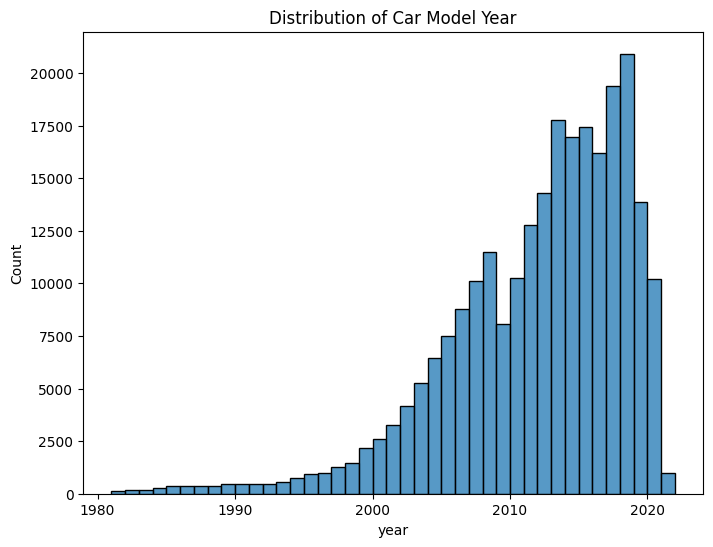

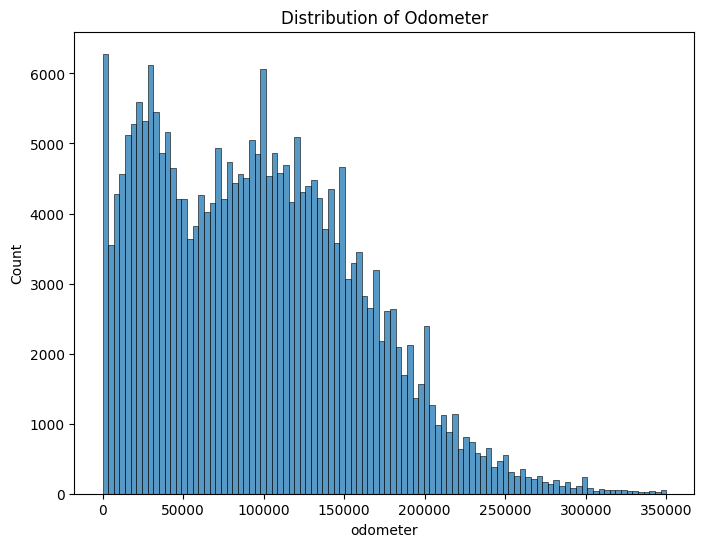

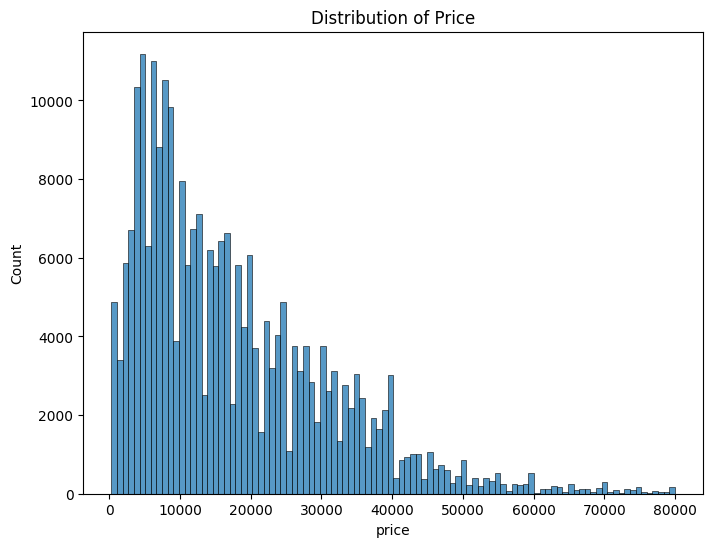

/tmp/ipykernel_247420/3023334624.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cylinders', data=df, palette='viridis')


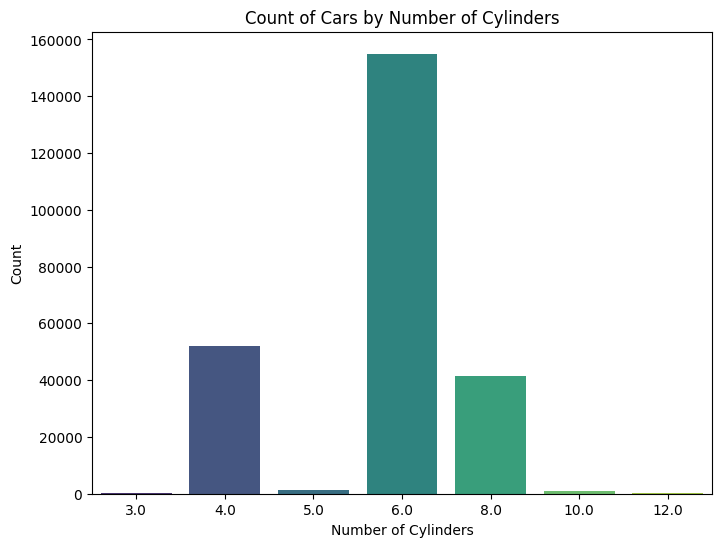

In [17]:
# --- Plot 1: Histogram for 'year' ---
# We use binwidth=1 to get a separate bar for each year.
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='year', binwidth=1)
plt.title('Distribution of Car Model Year')
plt.show()


# --- Plot 2: Histogram for 'odometer' ---
# Your plot has many bins. The default 'auto' might work,
# but setting a specific number like bins=100 gives this granular look.
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='odometer', bins=100)
plt.title('Distribution of Odometer')
plt.show()


# --- Plot 3: Histogram for 'price' ---
# This plot also has many bins, so we'll set bins=100 again.
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='price', bins=100)
plt.title('Distribution of Price')
plt.show()

# --- Plot 4: Count Plot for 'cylinders' ---
# This plot also has many bins, so we'll set bins=100 again.
plt.figure(figsize=(8, 6))
sns.countplot(x='cylinders', data=df, palette='viridis') 
plt.title('Count of Cars by Number of Cylinders')
plt.xlabel('Number of Cylinders')
plt.ylabel('Count')
plt.show()

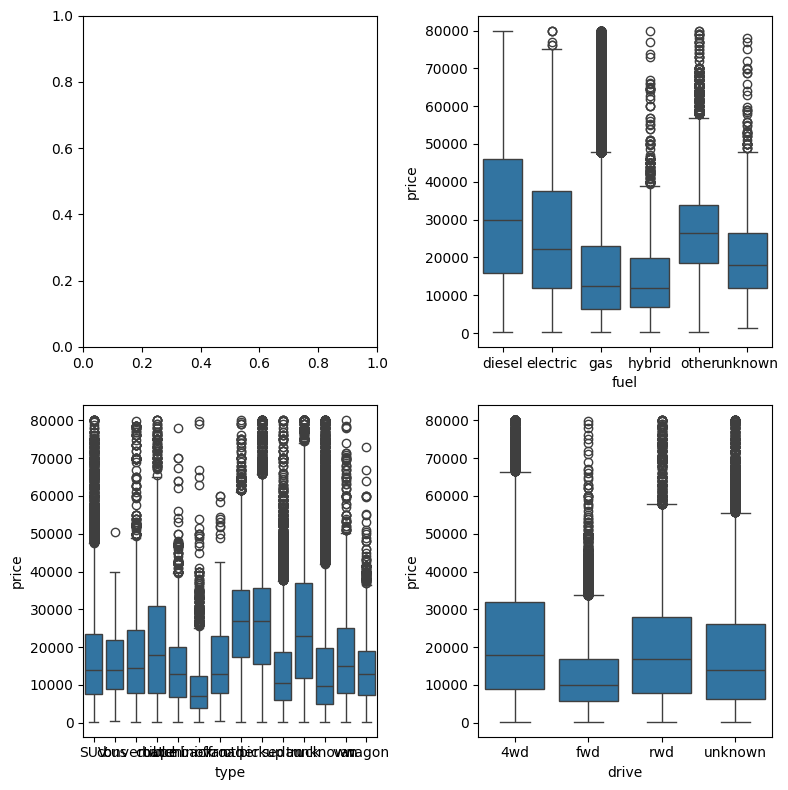

In [18]:
# Box plots for categorical variables
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
sns.boxplot(x='fuel', y='price', data=df, ax=axes[0, 1])
sns.boxplot(x='type', y='price', data=df, ax=axes[1, 0])
sns.boxplot(x='drive', y='price', data=df, ax=axes[1, 1])
plt.tight_layout()
plt.show()

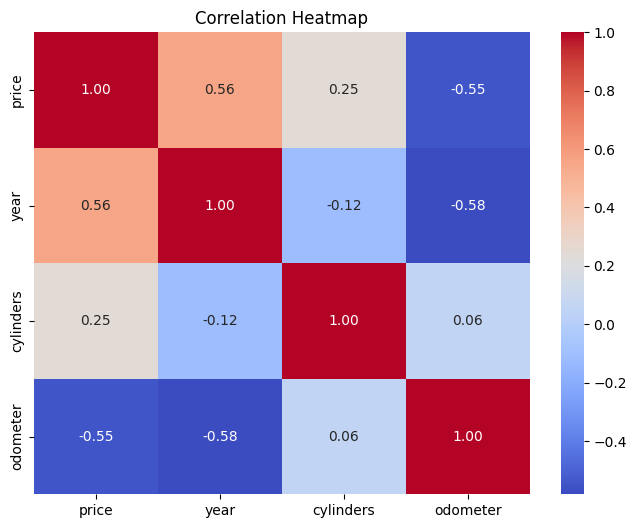

In [19]:
corr_matrix = df.select_dtypes(include="number").corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True,    
    cmap='coolwarm',
    fmt='.2f'      
)
plt.title('Correlation Heatmap')
plt.show()

In [20]:
# Add these before encoding:
df['age'] = 2025 - df['year']
df['odometer_per_year'] = df['odometer'] / df['age']
df['age_x_odometer'] = df['age'] * df['odometer']

# Log transform skewed features
df['log_odometer'] = np.log1p(df['odometer'])
df['log_price'] = np.log1p(df['price'])  # Use as target for better distribution

# Brand tier (luxury vs economy)
luxury_brands = ['bmw', 'mercedes-benz', 'audi', 'lexus', 'porsche']
df['is_luxury'] = df['manufacturer'].isin(luxury_brands).astype(int)

# Age bins
df['age_group'] = pd.cut(df['age'], bins=[0, 3, 7, 15, 50], 
                         labels=['new', 'recent', 'mid', 'old'])

# Mileage per year bins
df['usage_intensity'] = pd.cut(df['odometer_per_year'], 
                               bins=[0, 8000, 12000, 20000, np.inf],
                               labels=['low', 'normal', 'high', 'extreme'])

# Interaction: luxury × age
df['luxury_age_interaction'] = df['is_luxury'] * df['age']

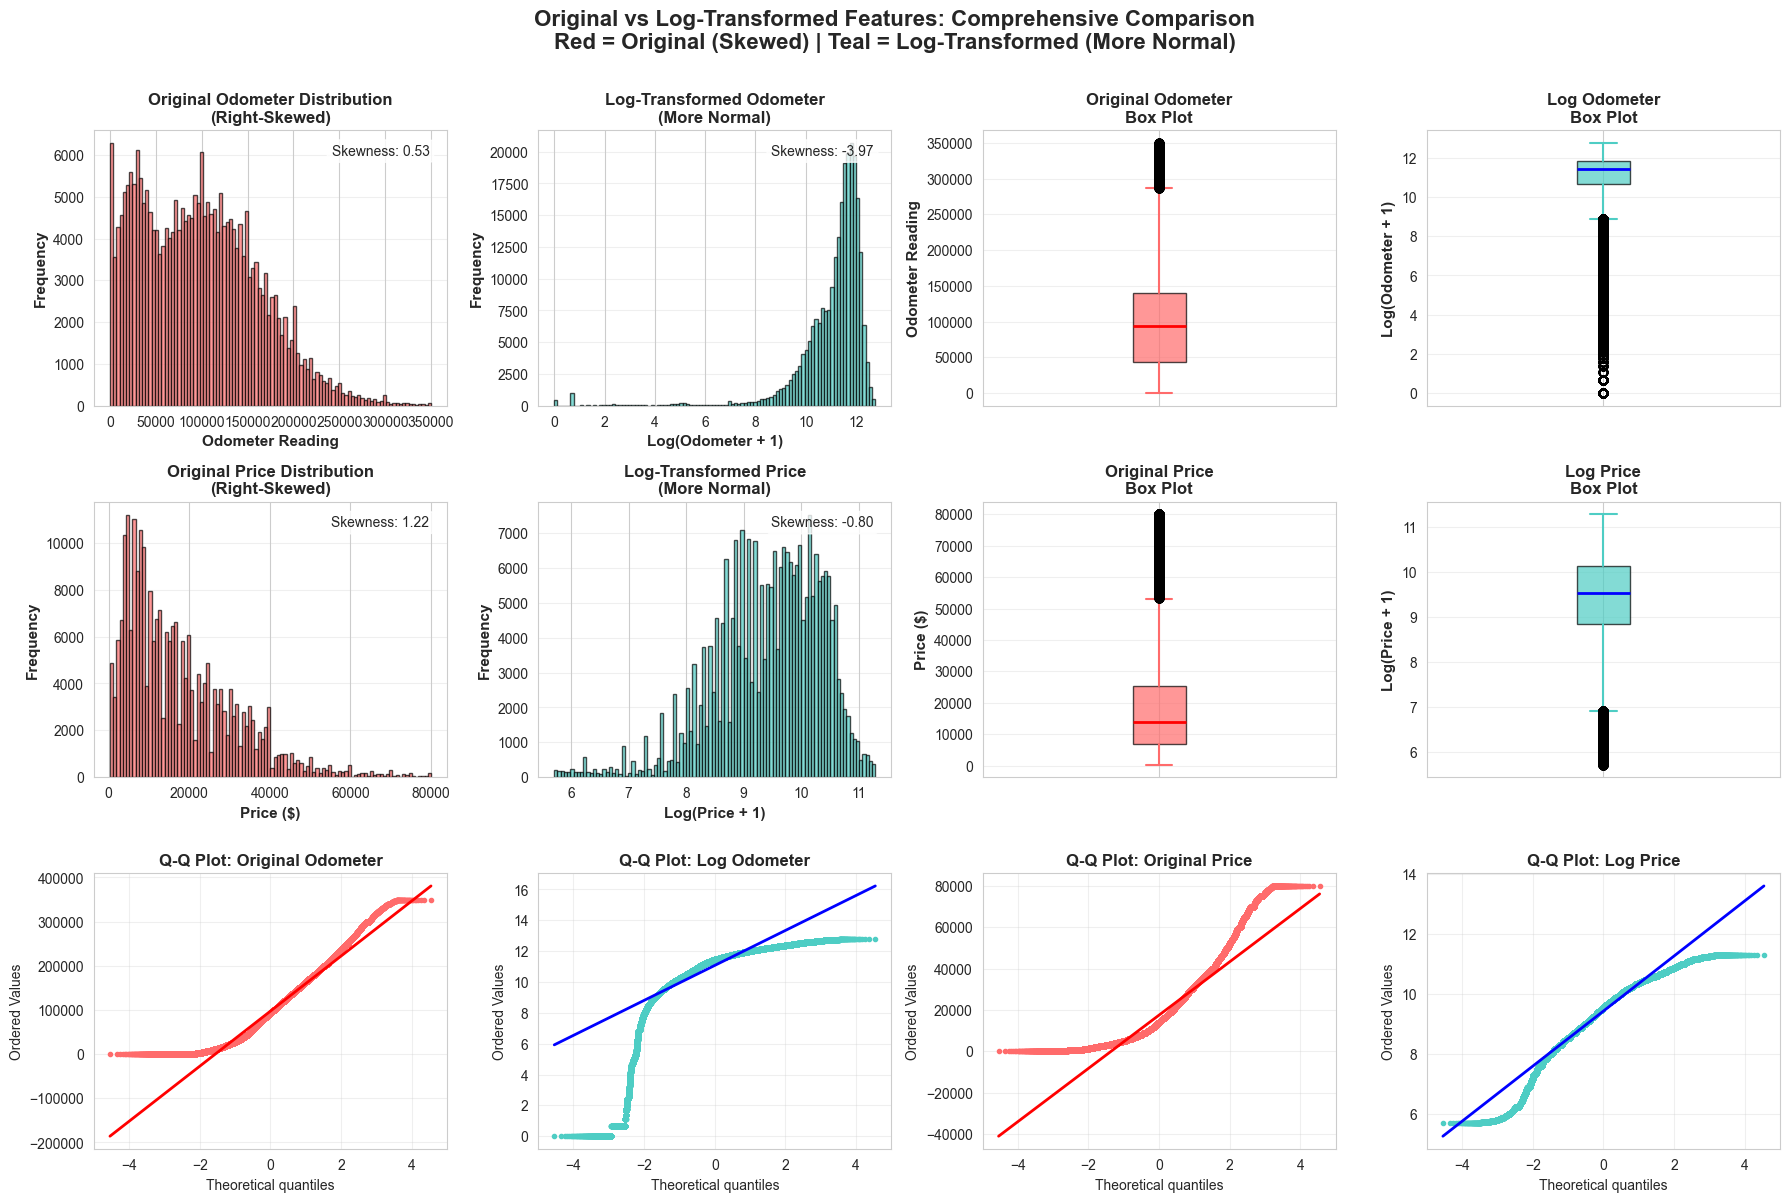


STATISTICAL COMPARISON: ORIGINAL vs LOG-TRANSFORMED

📊 ODOMETER STATISTICS:
----------------------------------------------------------------------
Metric                    Original             Log-Transformed     
----------------------------------------------------------------------
Mean                               97,422.85              11.08
Median                             93,424.00              11.44
Std Dev                            63,431.76               1.39
Skewness                                0.53              -3.97
Min                                     0.00               0.00
Max                               350,000.00              12.77

💰 PRICE STATISTICS:
----------------------------------------------------------------------
Metric                    Original             Log-Transformed     
----------------------------------------------------------------------
Mean                      $        17,564.04               9.42
Median                    $       

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Create figure with subplots
fig = plt.figure(figsize=(18, 12))

# Set style
sns.set_style("whitegrid")

# ============================================================
# ROW 1: ODOMETER DISTRIBUTIONS
# ============================================================

# 1. Original Odometer Distribution
ax1 = plt.subplot(3, 4, 1)
ax1.hist(df['odometer'], bins=100, color='#FF6B6B', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Odometer Reading', fontsize=11, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax1.set_title('Original Odometer Distribution\n(Right-Skewed)', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
# Add skewness
skew_odom = stats.skew(df['odometer'])
ax1.text(0.95, 0.95, f'Skewness: {skew_odom:.2f}', 
         transform=ax1.transAxes, ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 2. Log Odometer Distribution
ax2 = plt.subplot(3, 4, 2)
ax2.hist(df['log_odometer'], bins=100, color='#4ECDC4', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Log(Odometer + 1)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax2.set_title('Log-Transformed Odometer\n(More Normal)', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
# Add skewness
skew_log_odom = stats.skew(df['log_odometer'])
ax2.text(0.95, 0.95, f'Skewness: {skew_log_odom:.2f}', 
         transform=ax2.transAxes, ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 3. Original Odometer Box Plot
ax3 = plt.subplot(3, 4, 3)
box1 = ax3.boxplot(df['odometer'], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#FF6B6B', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2),
                    whiskerprops=dict(color='#FF6B6B', linewidth=1.5),
                    capprops=dict(color='#FF6B6B', linewidth=1.5))
ax3.set_ylabel('Odometer Reading', fontsize=11, fontweight='bold')
ax3.set_title('Original Odometer\nBox Plot', fontsize=12, fontweight='bold')
ax3.set_xticklabels([''])
ax3.grid(axis='y', alpha=0.3)

# 4. Log Odometer Box Plot
ax4 = plt.subplot(3, 4, 4)
box2 = ax4.boxplot(df['log_odometer'], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#4ECDC4', alpha=0.7),
                    medianprops=dict(color='blue', linewidth=2),
                    whiskerprops=dict(color='#4ECDC4', linewidth=1.5),
                    capprops=dict(color='#4ECDC4', linewidth=1.5))
ax4.set_ylabel('Log(Odometer + 1)', fontsize=11, fontweight='bold')
ax4.set_title('Log Odometer\nBox Plot', fontsize=12, fontweight='bold')
ax4.set_xticklabels([''])
ax4.grid(axis='y', alpha=0.3)

# ============================================================
# ROW 2: PRICE DISTRIBUTIONS
# ============================================================

# 5. Original Price Distribution
ax5 = plt.subplot(3, 4, 5)
ax5.hist(df['price'], bins=100, color='#FF6B6B', alpha=0.7, edgecolor='black')
ax5.set_xlabel('Price ($)', fontsize=11, fontweight='bold')
ax5.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax5.set_title('Original Price Distribution\n(Right-Skewed)', fontsize=12, fontweight='bold')
ax5.grid(axis='y', alpha=0.3)
# Add skewness
skew_price = stats.skew(df['price'])
ax5.text(0.95, 0.95, f'Skewness: {skew_price:.2f}', 
         transform=ax5.transAxes, ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 6. Log Price Distribution
ax6 = plt.subplot(3, 4, 6)
ax6.hist(df['log_price'], bins=100, color='#4ECDC4', alpha=0.7, edgecolor='black')
ax6.set_xlabel('Log(Price + 1)', fontsize=11, fontweight='bold')
ax6.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax6.set_title('Log-Transformed Price\n(More Normal)', fontsize=12, fontweight='bold')
ax6.grid(axis='y', alpha=0.3)
# Add skewness
skew_log_price = stats.skew(df['log_price'])
ax6.text(0.95, 0.95, f'Skewness: {skew_log_price:.2f}', 
         transform=ax6.transAxes, ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 7. Original Price Box Plot
ax7 = plt.subplot(3, 4, 7)
box3 = ax7.boxplot(df['price'], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#FF6B6B', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2),
                    whiskerprops=dict(color='#FF6B6B', linewidth=1.5),
                    capprops=dict(color='#FF6B6B', linewidth=1.5))
ax7.set_ylabel('Price ($)', fontsize=11, fontweight='bold')
ax7.set_title('Original Price\nBox Plot', fontsize=12, fontweight='bold')
ax7.set_xticklabels([''])
ax7.grid(axis='y', alpha=0.3)

# 8. Log Price Box Plot
ax8 = plt.subplot(3, 4, 8)
box4 = ax8.boxplot(df['log_price'], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#4ECDC4', alpha=0.7),
                    medianprops=dict(color='blue', linewidth=2),
                    whiskerprops=dict(color='#4ECDC4', linewidth=1.5),
                    capprops=dict(color='#4ECDC4', linewidth=1.5))
ax8.set_ylabel('Log(Price + 1)', fontsize=11, fontweight='bold')
ax8.set_title('Log Price\nBox Plot', fontsize=12, fontweight='bold')
ax8.set_xticklabels([''])
ax8.grid(axis='y', alpha=0.3)

# ============================================================
# ROW 3: Q-Q PLOTS (Test for Normality)
# ============================================================

# 9. Q-Q Plot - Original Odometer
ax9 = plt.subplot(3, 4, 9)
stats.probplot(df['odometer'], dist="norm", plot=ax9)
ax9.set_title('Q-Q Plot: Original Odometer', fontsize=12, fontweight='bold')
ax9.get_lines()[0].set_color('#FF6B6B')
ax9.get_lines()[0].set_markersize(3)
ax9.get_lines()[1].set_color('red')
ax9.get_lines()[1].set_linewidth(2)
ax9.grid(alpha=0.3)

# 10. Q-Q Plot - Log Odometer
ax10 = plt.subplot(3, 4, 10)
stats.probplot(df['log_odometer'], dist="norm", plot=ax10)
ax10.set_title('Q-Q Plot: Log Odometer', fontsize=12, fontweight='bold')
ax10.get_lines()[0].set_color('#4ECDC4')
ax10.get_lines()[0].set_markersize(3)
ax10.get_lines()[1].set_color('blue')
ax10.get_lines()[1].set_linewidth(2)
ax10.grid(alpha=0.3)

# 11. Q-Q Plot - Original Price
ax11 = plt.subplot(3, 4, 11)
stats.probplot(df['price'], dist="norm", plot=ax11)
ax11.set_title('Q-Q Plot: Original Price', fontsize=12, fontweight='bold')
ax11.get_lines()[0].set_color('#FF6B6B')
ax11.get_lines()[0].set_markersize(3)
ax11.get_lines()[1].set_color('red')
ax11.get_lines()[1].set_linewidth(2)
ax11.grid(alpha=0.3)

# 12. Q-Q Plot - Log Price
ax12 = plt.subplot(3, 4, 12)
stats.probplot(df['log_price'], dist="norm", plot=ax12)
ax12.set_title('Q-Q Plot: Log Price', fontsize=12, fontweight='bold')
ax12.get_lines()[0].set_color('#4ECDC4')
ax12.get_lines()[0].set_markersize(3)
ax12.get_lines()[1].set_color('blue')
ax12.get_lines()[1].set_linewidth(2)
ax12.grid(alpha=0.3)

# Add main title
plt.suptitle('Original vs Log-Transformed Features: Comprehensive Comparison\n' + 
             'Red = Original (Skewed) | Teal = Log-Transformed (More Normal)',
             fontsize=16, fontweight='bold', y=0.998)

plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

# ============================================================
# PRINT STATISTICS
# ============================================================
print("\n" + "=" * 70)
print("STATISTICAL COMPARISON: ORIGINAL vs LOG-TRANSFORMED")
print("=" * 70)

print("\n📊 ODOMETER STATISTICS:")
print("-" * 70)
print(f"{'Metric':<25} {'Original':<20} {'Log-Transformed':<20}")
print("-" * 70)
print(f"{'Mean':<25} {df['odometer'].mean():>18,.2f} {df['log_odometer'].mean():>18,.2f}")
print(f"{'Median':<25} {df['odometer'].median():>18,.2f} {df['log_odometer'].median():>18,.2f}")
print(f"{'Std Dev':<25} {df['odometer'].std():>18,.2f} {df['log_odometer'].std():>18,.2f}")
print(f"{'Skewness':<25} {skew_odom:>18,.2f} {skew_log_odom:>18,.2f}")
print(f"{'Min':<25} {df['odometer'].min():>18,.2f} {df['log_odometer'].min():>18,.2f}")
print(f"{'Max':<25} {df['odometer'].max():>18,.2f} {df['log_odometer'].max():>18,.2f}")

print("\n💰 PRICE STATISTICS:")
print("-" * 70)
print(f"{'Metric':<25} {'Original':<20} {'Log-Transformed':<20}")
print("-" * 70)
print(f"{'Mean':<25} ${df['price'].mean():>17,.2f} {df['log_price'].mean():>18,.2f}")
print(f"{'Median':<25} ${df['price'].median():>17,.2f} {df['log_price'].median():>18,.2f}")
print(f"{'Std Dev':<25} ${df['price'].std():>17,.2f} {df['log_price'].std():>18,.2f}")
print(f"{'Skewness':<25} {skew_price:>18,.2f} {skew_log_price:>18,.2f}")
print(f"{'Min':<25} ${df['price'].min():>17,.2f} {df['log_price'].min():>18,.2f}")
print(f"{'Max':<25} ${df['price'].max():>17,.2f} {df['log_price'].max():>18,.2f}")

print("\n✅ WHY LOG TRANSFORM?")
print("-" * 70)
print("• Reduces skewness (closer to 0 is better)")
print("• Makes data more normally distributed (Q-Q plots closer to line)")
print("• Reduces impact of outliers")
print("• Linear models work better with normal distributions")
print("• Stabilizes variance across the range")
print("=" * 70 + "\n")

# Feature Encoding

In [22]:

# Define the correct order, from worst to best
condition_order = ['salvage', 'fair', 'good', 'excellent', 'like new', 'new']


# Filter the list to only include categories present in your data
ordered_categories = [cat for cat in condition_order if cat in df['condition'].unique()]

# Initialize the encoder
ordinal_encoder = OrdinalEncoder(
    categories=[ordered_categories],
    handle_unknown='use_encoded_value', # Assigns a value (e.g., -1) to unknowns
    unknown_value=-1 
)

# Create the new encoded column
df['condition_encoded'] = ordinal_encoder.fit_transform(df[['condition']])
df = df.drop(columns=['condition'])

In [23]:
# Count frequency of each model
# model_counts = df['model'].value_counts()
# Keep only models that appear at least 50 times
# df = df[df['model'].isin(model_counts[model_counts >= 50].index)]


# Count frequency of each model
# manu_counts = df['manufacturer'].value_counts()
# Keep only manufacturer that appear at least 100 times
# df = df[df['manufacturer'].isin(manu_counts[manu_counts >= 100].index)]

In [24]:

low_cardinality_cols = ['fuel', 'transmission', 'drive', 'type', 'state', 'age_group', 'usage_intensity']

print(f"\n--- One-Hot Encoding for {low_cardinality_cols} ---")
print(f"Shape before OHE: {df.shape}")

# drop_first=True is often recommended to avoid multicollinearity
df = pd.get_dummies(df, columns=low_cardinality_cols, drop_first=True)

print(f"Shape after OHE: {df.shape}")


--- One-Hot Encoding for ['fuel', 'transmission', 'drive', 'type', 'state', 'age_group', 'usage_intensity'] ---
Shape before OHE: (250995, 21)
Shape after OHE: (250995, 93)


In [25]:
df

,price,year,manufacturer,model,cylinders,odometer,age,odometer_per_year,age_x_odometer,log_odometer,...,state_wa,state_wi,state_wv,state_wy,age_group_recent,age_group_mid,age_group_old,usage_intensity_normal,usage_intensity_high,usage_intensity_extreme
27,33590,2014.00,gmc,sierra 1500 crew cab slt,8.00,57923.00,11.00,5265.73,637153.00,10.97,...,False,False,False,False,False,True,False,False,False,False
28,22590,2010.00,chevrolet,silverado 1500,8.00,71229.00,15.00,4748.60,1068435.00,11.17,...,False,False,False,False,False,True,False,False,False,False
29,39590,2020.00,chevrolet,silverado 1500 crew,8.00,19160.00,5.00,3832.00,95800.00,9.86,...,False,False,False,False,True,False,False,False,False,False
30,30990,2017.00,toyota,tundra double cab sr,8.00,41124.00,8.00,5140.50,328992.00,10.62,...,False,False,False,False,False,True,False,False,False,False
31,15000,2013.00,ford,f-150 xlt,6.00,128000.00,12.00,10666.67,1536000.00,11.76,...,False,False,False,False,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,23590,2019.00,nissan,maxima s sedan 4d,6.00,32226.00,6.00,5371.00,193356.00,10.38,...,False,False,False,True,True,False,False,False,False,False
426876,30590,2020.00,volvo,s60 t5 momentum sedan 4d,6.00,12029.00,5.00,2405.80,60145.00,9.40,...,False,False,False,True,True,False,False,False,False,False
426877,34990,2020.00,cadillac,xt4 sport suv 4d,6.00,4174.00,5.00,834.80,20870.00,8.34,...,False,False,False,True,True,False,False,False,False,False
426878,28990,2018.00,lexus,es 350 sedan 4d,6.00,30112.00,7.00,4301.71,210784.00,10.31,...,False,False,False,True,True,False,False,False,False,False


In [26]:
df.columns

Index(['price', 'year', 'manufacturer', 'model', 'cylinders', 'odometer',
       'age', 'odometer_per_year', 'age_x_odometer', 'log_odometer',
       'log_price', 'is_luxury', 'luxury_age_interaction', 'condition_encoded',
       'fuel_electric', 'fuel_gas', 'fuel_hybrid', 'fuel_other',
       'fuel_unknown', 'transmission_manual', 'transmission_other',
       'drive_fwd', 'drive_rwd', 'drive_unknown', 'type_bus',
       'type_convertible', 'type_coupe', 'type_hatchback', 'type_mini-van',
       'type_offroad', 'type_other', 'type_pickup', 'type_sedan', 'type_truck',
       'type_unknown', 'type_van', 'type_wagon', 'state_al', 'state_ar',
       'state_az', 'state_ca', 'state_co', 'state_ct', 'state_dc', 'state_de',
       'state_fl', 'state_ga', 'state_hi', 'state_ia', 'state_id', 'state_il',
       'state_in', 'state_ks', 'state_ky', 'state_la', 'state_ma', 'state_md',
       'state_me', 'state_mi', 'state_mn', 'state_mo', 'state_ms', 'state_mt',
       'state_nc', 'state_nd', 'state

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 250995 entries, 27 to 426879
Data columns (total 93 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   price                    250995 non-null  int64   
 1   year                     250995 non-null  float64 
 2   manufacturer             250995 non-null  category
 3   model                    250995 non-null  category
 4   cylinders                250995 non-null  float64 
 5   odometer                 250995 non-null  float64 
 6   age                      250995 non-null  float64 
 7   odometer_per_year        250995 non-null  float64 
 8   age_x_odometer           250995 non-null  float64 
 9   log_odometer             250995 non-null  float64 
 10  log_price                250995 non-null  float64 
 11  is_luxury                250995 non-null  int64   
 12  luxury_age_interaction   250995 non-null  float64 
 13  condition_encoded        250995 non-null  float6

In [28]:
# def target_encode_kfold(df_to_encode, col_to_encode, target_col='log_price', n_splits=5):
#     """
#     Performs target encoding using K-Folds to prevent leakage.
#     Fills any remaining NaNs with the global mean of the target.
#     """
#     print(f"Target encoding: '{col_to_encode}' based on '{target_col}'...")
    
#     # CRITICAL: Reset index to ensure sequential 0-based indexing
#     df_to_encode = df_to_encode.reset_index(drop=True)
    
#     # Initialize with NaN as float64 explicitly
#     encoded_col_name = f"{col_to_encode}_target_enc"
#     encoded_values = np.full(len(df_to_encode), np.nan, dtype=np.float64)
    
#     # Calculate the global mean of the target to fill in rare categories
#     global_mean = df_to_encode[target_col].mean()
    
#     kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
#     # K-Fold Encoding
#     for train_idx, val_idx in kf.split(df_to_encode):
#         # Calculate means on the training part of the fold
#         means = df_to_encode.iloc[train_idx].groupby(col_to_encode, observed=True)[target_col].mean()
        
#         # Apply means to the validation part of the fold
#         mapped_values = df_to_encode.iloc[val_idx][col_to_encode].map(means)
#         encoded_values[val_idx] = mapped_values.values
    
#     # Fill any remaining NaNs (rare categories) with the global mean
#     encoded_values = np.where(np.isnan(encoded_values), global_mean, encoded_values)
    
#     # Add the encoded column to the dataframe
#     df_to_encode[encoded_col_name] = encoded_values
    
#     print(f"Encoding complete. Unique values encoded: {df_to_encode[col_to_encode].nunique()}")
#     return df_to_encode

# # IMPORTANT: Reset the index before target encoding
# df = df.reset_index(drop=True)

# # We use 'log_price' as the target column
# df = target_encode_kfold(df, 'manufacturer', target_col='log_price')
# df = target_encode_kfold(df, 'model', target_col='log_price')

# df = df.drop(columns=['manufacturer', 'model'])

In [29]:
# droping, price and log_price
X = df.drop(columns=['price', 'log_price'])
y = df['log_price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nSuccessfully split data. X_train shape: {X_train.shape}")


Successfully split data. X_train shape: (200796, 91)


In [30]:
# ============================================================
# FREQUENCY ENCODING FOR MANUFACTURER AND MODEL
# ============================================================

# # Calculate frequencies on training data only (to avoid leakage)
# manufacturer_freq = X_train['manufacturer'].value_counts()
# model_freq = X_train['model'].value_counts()

# # Apply frequency encoding to training set
# X_train['manufacturer_freq'] = X_train['manufacturer'].map(manufacturer_freq)
# X_train['model_freq'] = X_train['model'].map(model_freq)

# # Apply same frequencies to test set
# X_test['manufacturer_freq'] = X_test['manufacturer'].map(manufacturer_freq)
# X_test['model_freq'] = X_test['model'].map(model_freq)

# # Handle unseen categories in test set (fill with 0 or small value)
# X_train['manufacturer_freq'] = X_train['manufacturer_freq'].fillna(0)
# X_train['model_freq'] = X_train['model_freq'].fillna(0)

# X_test['manufacturer_freq'] = X_test['manufacturer_freq'].fillna(0)
# X_test['model_freq'] = X_test['model_freq'].fillna(0)

# # Drop original categorical columns
# X_train = X_train.drop(columns=['manufacturer', 'model'])
# X_test = X_test.drop(columns=['manufacturer', 'model'])

# print("--- Frequency Encoding Complete ---")
# print(f"X_train shape: {X_train.shape}")
# print(f"X_test shape: {X_test.shape}")
# print("\nSample frequencies:")
# print(X_train[['manufacturer_freq', 'model_freq']].head(10))


In [31]:
X_train.columns

Index(['year', 'manufacturer', 'model', 'cylinders', 'odometer', 'age',
       'odometer_per_year', 'age_x_odometer', 'log_odometer', 'is_luxury',
       'luxury_age_interaction', 'condition_encoded', 'fuel_electric',
       'fuel_gas', 'fuel_hybrid', 'fuel_other', 'fuel_unknown',
       'transmission_manual', 'transmission_other', 'drive_fwd', 'drive_rwd',
       'drive_unknown', 'type_bus', 'type_convertible', 'type_coupe',
       'type_hatchback', 'type_mini-van', 'type_offroad', 'type_other',
       'type_pickup', 'type_sedan', 'type_truck', 'type_unknown', 'type_van',
       'type_wagon', 'state_al', 'state_ar', 'state_az', 'state_ca',
       'state_co', 'state_ct', 'state_dc', 'state_de', 'state_fl', 'state_ga',
       'state_hi', 'state_ia', 'state_id', 'state_il', 'state_in', 'state_ks',
       'state_ky', 'state_la', 'state_ma', 'state_md', 'state_me', 'state_mi',
       'state_mn', 'state_mo', 'state_ms', 'state_mt', 'state_nc', 'state_nd',
       'state_ne', 'state_nh', 'sta

In [32]:
# We need y_train (log_price) to create the encodings
X_train_with_target = X_train.join(y_train)

# 1. Manufacturer Target Encoding
manu_target_map = X_train_with_target.groupby('manufacturer', observed=True)['log_price'].mean()

# Apply the map and CONVERT TO FLOAT immediately
X_train['manufacturer_encoded'] = X_train['manufacturer'].map(manu_target_map).astype(float)
X_test['manufacturer_encoded'] = X_test['manufacturer'].map(manu_target_map).astype(float)

# 2. Model Target Encoding
model_target_map = X_train_with_target.groupby('model', observed=True)['log_price'].mean()

# Apply the map and CONVERT TO FLOAT immediately
X_train['model_target_enc'] = X_train['model'].map(model_target_map).astype(float)
X_test['model_target_enc'] = X_test['model'].map(model_target_map).astype(float)

# 3. Handle NaNs - Now this will work since columns are float
global_mean_log_price = y_train.mean()

X_train['manufacturer_encoded'] = X_train['manufacturer_encoded'].fillna(global_mean_log_price)
X_test['manufacturer_encoded'] = X_test['manufacturer_encoded'].fillna(global_mean_log_price)

X_train['model_target_enc'] = X_train['model_target_enc'].fillna(global_mean_log_price)
X_test['model_target_enc'] = X_test['model_target_enc'].fillna(global_mean_log_price)

# 4. Drop the original object columns
X_train = X_train.drop(columns=['manufacturer', 'model'])
X_test = X_test.drop(columns=['manufacturer', 'model'])


print("--- Target Encoding Complete ---")
print(f"X_train shape after encoding: {X_train.shape}")
print(f"X_test shape after encoding: {X_test.shape}")
print("\nFirst 5 rows of X_train with new encoded features:")
print(X_train[['manufacturer_encoded', 'model_target_enc']].head())

--- Target Encoding Complete ---
X_train shape after encoding: (200796, 91)
X_test shape after encoding: (50199, 91)

First 5 rows of X_train with new encoded features:
        manufacturer_encoded  model_target_enc
339702                  9.52              8.43
140864                  9.15              9.32
84955                  10.03              9.82
56854                   9.45              9.62
188492                  9.65              9.65


In [34]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Successfully scaled training and test data.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")

Successfully scaled training and test data.
X_train_scaled shape: (200796, 91)


In [35]:
lasso_model = Lasso(alpha=0.0001, max_iter=5000)
lasso_model.fit(X_train_scaled, y_train)

lasso_y_pred = lasso_model.predict(X_test_scaled)

lasso_mae = mean_absolute_error(y_test, lasso_y_pred)
lasso_rmse = root_mean_squared_error(y_test, lasso_y_pred)
lasso_r2 = r2_score(y_test, lasso_y_pred)

print(f"Lasso MAE : {lasso_mae:,.2f}")
print(f"Lasso RMSE: {lasso_rmse:,.2f}")
print(f"Lasso R²  : {lasso_r2:.4f}")
print(lasso_model.coef_)

print(f"Nonzero Coefficients: {(lasso_model.coef_ != 0).sum()} / {len(lasso_model.coef_)}")
if hasattr(lasso_model, 'n_iter_'):
    print(f"Converged in {lasso_model.n_iter_} iterations")

Lasso MAE : 0.34
Lasso RMSE: 0.57
Lasso R²  : 0.6177
[ 1.57598857e-01  6.75650715e-02 -5.72565730e-01 -4.74001115e-03
  1.17560767e-01  1.42624945e-01  1.10398609e-01 -1.60804968e-02
  3.30957178e-02  6.14550186e-03 -2.65259626e-02 -1.20072789e-01
 -3.54865352e-02 -8.33962342e-02 -1.97461040e-02  1.23849474e-02
 -3.71585292e-02 -5.23358980e-02 -2.13247524e-02 -5.98432692e-02
  3.71925057e-03  1.90786324e-02  5.92575947e-03 -1.25974269e-02
  2.10116078e-03  6.68913315e-03  1.27036552e-02  2.61869136e-02
 -1.15663904e-02  2.12198346e-03 -1.56052968e-03  9.07083112e-03
 -3.10748373e-04 -3.17866520e-03 -4.97244255e-03 -1.53939591e-02
 -2.67303043e-02 -4.92693658e-03 -2.59169940e-02 -1.18653761e-02
 -7.98975674e-03 -3.53937364e-02 -1.40062815e-02 -1.12220016e-02
 -1.06881068e-02 -1.38125656e-02 -3.22993724e-02 -1.26945514e-02
 -1.00032652e-02 -9.10789789e-03 -5.32254045e-03 -2.87301294e-02
 -2.00027277e-02 -1.08528825e-02 -3.81828740e-02 -2.18479597e-02
 -6.38380623e-03 -5.19651471e-03 -6.1

/home/miad/.local/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.890e+01, tolerance: 1.763e+01
  model = cd_fast.enet_coordinate_descent(


In [36]:
ridge_model = Ridge(alpha=0.01, max_iter=1000)
ridge_model.fit(X_train_scaled, y_train)

ridge_y_pred = ridge_model.predict(X_test_scaled)

ridge_mae = mean_absolute_error(y_test, ridge_y_pred)
ridge_rmse = root_mean_squared_error(y_test, ridge_y_pred)
ridge_r2 = r2_score(y_test, ridge_y_pred)

print(f"Ridge MAE : {ridge_mae:,.2f}")
print(f"Ridge RMSE: {ridge_rmse:,.2f}")
print(f"Ridge R²  : {ridge_r2:.4f}")

# --- Diagnostics ---
print(f"Nonzero Coefficients: {(ridge_model.coef_ != 0).sum()} / {len(ridge_model.coef_)}")
if hasattr(ridge_model, 'n_iter_'):
    print(f"Converged in {ridge_model.n_iter_} iterations")

Ridge MAE : 0.34
Ridge RMSE: 0.57
Ridge R²  : 0.6181
Nonzero Coefficients: 91 / 91
Converged in None iterations


In [37]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

linear_y_pred = linear_model.predict(X_test_scaled)

linear_mae = mean_absolute_error(y_test, linear_y_pred)
linear_rmse = root_mean_squared_error(y_test, linear_y_pred)
linear_r2 = r2_score(y_test, linear_y_pred)

print(f"Linear MAE : {linear_mae:,.2f}")
print(f"Linear RMSE: {linear_rmse:,.2f}")
print(f"Linear R²  : {linear_r2:.4f}")

# --- Diagnostics ---
print(f"Nonzero Coefficients: {(linear_model.coef_ != 0).sum()} / {len(linear_model.coef_)}")

Linear MAE : 0.34
Linear RMSE: 0.57
Linear R²  : 0.6181
Nonzero Coefficients: 91 / 91


In [38]:
# --- Create Polynomial Pipeline (degree=2 as example) ---
degree = 2
poly_model = make_pipeline(PolynomialFeatures(degree=degree, include_bias=False),
                           LinearRegression())

poly_model.fit(X_train_scaled, y_train)

poly_y_pred = poly_model.predict(X_test_scaled)

poly_mae = mean_absolute_error(y_test, poly_y_pred)
poly_rmse = root_mean_squared_error(y_test, poly_y_pred)
poly_r2 = r2_score(y_test, poly_y_pred)

print(f"Poly({degree}) MAE : {poly_mae:,.2f}")
print(f"Poly({degree}) RMSE: {poly_rmse:,.2f}")
print(f"Poly({degree}) R²  : {poly_r2:.4f}")


poly_step = poly_model.named_steps['linearregression']

print(f"Nonzero Coefficients: {(poly_step.coef_ != 0).sum()} / {len(poly_step.coef_)}")

Poly(2) MAE : 0.38
Poly(2) RMSE: 10.60
Poly(2) R²  : -129.1059
Nonzero Coefficients: 4277 / 4277


In [39]:
# Degree 2 → include squares and pairwise interactions
lasso_poly = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    Lasso(alpha=0.001, max_iter=1000)
)

lasso_poly.fit(X_train_scaled, y_train)

lasso_poly_pred = lasso_poly.predict(X_test_scaled)

lasso_poly_mae = mean_absolute_error(y_test, lasso_poly_pred)
lasso_poly_rmse = root_mean_squared_error(y_test, lasso_poly_pred)
lasso_poly_r2 = r2_score(y_test, lasso_poly_pred)

print(f"LassoPoly(2) MAE : {lasso_poly_mae:,.2f}")
print(f"LassoPoly(2) RMSE: {lasso_poly_rmse:,.2f}")
print(f"LassoPoly(2) R²  : {lasso_poly_r2:.4f}")

lasso_step = lasso_poly.named_steps['lasso']

print(f"Nonzero Coefficients: {(lasso_step.coef_ != 0).sum()} / {len(lasso_step.coef_)}")
print(f"Converged in {lasso_step.n_iter_} iterations")

/home/miad/.local/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.667e+01, tolerance: 1.763e+01
  model = cd_fast.enet_coordinate_descent(


LassoPoly(2) MAE : 0.32
LassoPoly(2) RMSE: 0.54
LassoPoly(2) R²  : 0.6586
Nonzero Coefficients: 1209 / 4277
Converged in 1000 iterations


In [40]:
from sklearn.ensemble import RandomForestRegressor

# Note: Tree-based models don't need scaled data, use original X_train/X_test
rf_model = RandomForestRegressor(
    n_estimators=100,      # Number of trees
    max_depth=20,          # Maximum depth of trees
    min_samples_split=5,   # Minimum samples to split a node
    min_samples_leaf=2,    # Minimum samples in leaf node
    max_features='sqrt',   # Features to consider for best split
    random_state=42,
    n_jobs=-1              # Use all CPU cores
)
rf_model.fit(X_train, y_train)

rf_y_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_y_pred)
rf_rmse = root_mean_squared_error(y_test, rf_y_pred)
rf_r2 = r2_score(y_test, rf_y_pred)

print(f"Random Forest MAE : {rf_mae:,.4f}")
print(f"Random Forest RMSE: {rf_rmse:,.4f}")
print(f"Random Forest R²  : {rf_r2:.4f}")

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))


Random Forest MAE : 0.2807
Random Forest RMSE: 0.5118
Random Forest R²  : 0.6964

Top 10 Most Important Features:
             feature  importance
    model_target_enc        0.22
                year        0.10
                 age        0.10
      age_x_odometer        0.10
            odometer        0.07
        log_odometer        0.07
       age_group_old        0.06
manufacturer_encoded        0.04
           cylinders        0.03
   odometer_per_year        0.03


In [ ]:
# XGBoost GridSearch Phase 2
xgb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 6, 8],
    # 'min_child_weight': [1, 3, 5],
    # 'subsample': [0.7, 0.8, 0.9],
    # 'colsample_bytree': [0.7, 0.8, 0.9]
}

xgb_grid = GridSearchCV(XGBRegressor(
    random_state=42,
    n_jobs=-1,
    tree_method='hist',         # Faster training method 'hist' works on both GPU/CPU
    device='cuda'              # 'cuda' for GPU, 'cpu' for CPU
), xgb_params, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)

xgb_grid.fit(X_train, y_train)
print(f"Best params: {xgb_grid.best_params_}")
print(f"Best score: {xgb_grid.best_score_}")


Traceback (most recent call last):
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /dev/shm/joblib_memmapping_folder_209999_3038b7c36b27406283cfea391e969dd3_b7f57541883744fdb57c8cc9bde0ec45 for automatic cleanup: unknown resource type folder
Traceback (most recent call last):
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /dev/shm/joblib_memmapping_folder_209999_85f70fbb51d549e4b643083fe8492af8_3c30d19e54a44f70afb0ac15be4d27f2 for automatic cleanup: unknown resource type folder
Traceback (most recent call last):
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueErro

Best params: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 300}
Best score: -0.2456091901501333


In [ ]:
# XGBoost GridSearch Phase 2
xgb_params = {
    'n_estimators': [300],
    'learning_rate': [0.1],
    'max_depth': [8],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

xgb_grid = GridSearchCV(XGBRegressor(random_state=42,
    n_jobs=-1,
    tree_method='hist',         # Faster training method 'hist' works on both GPU/CPU
    device='cuda'              # 'cuda' for GPU, 'cpu' for CPU
), xgb_params, cv=4, scoring='neg_mean_absolute_error', n_jobs=-1)

xgb_grid.fit(X_train, y_train)
print(f"Best params: {xgb_grid.best_params_}")
print(f"Best score: {xgb_grid.best_score_}")


Traceback (most recent call last):
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /dev/shm/joblib_memmapping_folder_209999_0b940b48b6284daaba730409a333f977_fd2e1e4a5b0542ae83a3e6772b37dc1d for automatic cleanup: unknown resource type folder
Traceback (most recent call last):
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /dev/shm/joblib_memmapping_folder_209999_85f70fbb51d549e4b643083fe8492af8_b948e6db8307448b80f836a9439a2f04 for automatic cleanup: unknown resource type folder
Traceback (most recent call last):
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueErro

Best params: {'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': 8, 'min_child_weight': 5, 'n_estimators': 300, 'subsample': 0.9}
Best score: -0.2438928826337973


In [41]:
xgb_model = XGBRegressor(
    n_estimators=300,          # Number of boosting rounds
    learning_rate=0.1,         # Step size shrinkage
    max_depth=8,               # Maximum tree depth
    min_child_weight=5,        # Minimum sum of instance weight in child
    subsample=0.9,             # Fraction of samples used per tree
    colsample_bytree=0.9,      # Fraction of features used per tree
    random_state=42,
    n_jobs=-1,
    tree_method='hist',         # Faster training method 'hist' works on both GPU/CPU
    device='cuda'              # 'cuda' for GPU, 'cpu' for CPU
)
xgb_model.fit(X_train, y_train)

xgb_y_pred = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_y_pred)
xgb_rmse = root_mean_squared_error(y_test, xgb_y_pred)
xgb_r2 = r2_score(y_test, xgb_y_pred)

print(f"XGBoost MAE : {xgb_mae:,.4f}")
print(f"XGBoost RMSE: {xgb_rmse:,.4f}")
print(f"XGBoost R²  : {xgb_r2:.4f}")

xgb_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(xgb_importance.head(10).to_string(index=False))


XGBoost MAE : 0.2606
XGBoost RMSE: 0.4872
XGBoost R²  : 0.7250

Top 10 Most Important Features:
         feature  importance
   age_group_old        0.59
model_target_enc        0.05
            year        0.03
age_group_recent        0.02
  age_x_odometer        0.02
        fuel_gas        0.02
      fuel_other        0.01
        state_or        0.01
        state_mi        0.01
       cylinders        0.01


/home/miad/.local/lib/python3.13/site-packages/xgboost/core.py:774: UserWarning: [23:27:43] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
